# Fig. 3(b) Reproduction With `bloqade-decoders`

This notebook reproduces the Gemini logical simulator workflow for Fig. 3(b) of `arXiv:2412.15165v1`, while using the decoder implementations from the local `bloqade-decoders` checkout instead of notebook-local decoder code.

What is notebook-local vs decoder-local here:
- The Gemini logical hardware kernels, detector mappings, simulator tasks, tomography, and plotting live in this notebook.
- The MLE decoder is `GurobiDecoder` from the local `bloqade-decoders` repo, using its paper-style logical-gap confidence score.
- The MLD decoder is `TableDecoder` from the local `bloqade-decoders` repo, trained from simulator samples. Its confidence score here is the empirical posterior mass of the selected logical correction for a given detector syndrome.

Notes:
- The paper's exact MLD postselection ranks syndrome patterns by the output fidelity they induce. In this notebook we instead use the decoder-native confidence available from `TableDecoder`'s learned counts.
- The notebook prepends the sibling `../bloqade-decoders/src` path so it uses the current working tree, including the new MLE logical-gap support.
- The default configuration is interactive rather than paper-scale.


In [36]:
import math
import sys
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import stim
from beliefmatching import detector_error_model_to_check_matrices
from bloqade import qubit, squin
from bloqade.gemini import logical as gemini_logical
from bloqade.gemini.logical.stdlib import default_post_processing
from bloqade.lanes import GeminiLogicalSimulator
from bloqade.lanes.analysis import atom
from bloqade.lanes.arch.gemini.impls import generate_arch_hypercube
from bloqade.lanes.device import GeminiLogicalSimulatorTask
from bloqade.lanes.logical_mvp import append_measurements_and_annotations, compile_squin_to_move
from bloqade.lanes.transform import MoveToSquin
from bloqade.lanes.steane_defaults import steane7_m2dets, steane7_m2obs
from kirin.dialects import ilist
from scipy.special import logsumexp

LOCAL_DECODER_SRC_CANDIDATES = [
    Path.cwd() / '..' / 'bloqade-decoders' / 'src',
    Path.cwd() / 'bloqade-decoders' / 'src',
    Path.cwd().parent / 'bloqade-decoders' / 'src',
    Path.cwd().parent.parent / 'bloqade-decoders' / 'src',
]
for candidate in LOCAL_DECODER_SRC_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError('Could not locate sibling bloqade-decoders/src checkout.')

import bloqade.decoders as bloqade_decoders
from bloqade.decoders import GurobiDecoder, TableDecoder

print('Using bloqade.decoders from:', Path(bloqade_decoders.__file__).resolve())


Using bloqade.decoders from: /Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-decoders/src/bloqade/decoders/__init__.py


In [37]:
FAST_CONFIG = {
    'mld_train_shots': 20_000,
    'eval_shots': 4_000,
    'posterior_samples': 20_000,
    'mle_threshold_points': 24,
    'mld_threshold_points': 24,
}

PAPER_SCALE_CONFIG = {
    'mld_train_shots': 1_000_000_000,
    'eval_shots': 250_000,
    'posterior_samples': 200_000,
    'mle_threshold_points': 64,
    'mld_threshold_points': 64,
}

# FAST_CONFIG["eval_shots"] = 250_000
# FAST_CONFIG["posterior_samples"] = 200_000
CONFIG = FAST_CONFIG.copy()

BASIS_LABELS = ('X', 'Y', 'Z')
OUTPUT_QUBIT = 0
ANCILLA_QUBITS = (1, 2, 3, 4)
# FACTORY_TARGET = np.array([0, 0, 1, 1], dtype=np.uint8)
FACTORY_TARGET = np.array([0, 0, 0, 0], dtype=np.uint8)
SQRT3 = np.sqrt(3.0)

M2DETS_5 = steane7_m2dets(5)
M2OBS_5 = steane7_m2obs(5)
M2DETS_1 = steane7_m2dets(1)
M2OBS_1 = steane7_m2obs(1)


def bits_to_key(bits: np.ndarray | list[bool] | list[int]) -> str:
    return ''.join('1' if int(x) else '0' for x in bits)


def key_to_bits(key: str) -> np.ndarray:
    return np.fromiter((1 if c == '1' else 0 for c in key), dtype=np.uint8)


def logical_expectation(bits: np.ndarray) -> float:
    if len(bits) == 0:
        return float('nan')
    return float(np.mean(1.0 - 2.0 * bits.astype(np.float64)))


def pack_boolean_array(arr: np.ndarray) -> np.ndarray:
    return np.sum(arr.astype(np.uint64) << np.arange(arr.shape[1], dtype=np.uint64), axis=1)


@squin.kernel
def msd_magic_prep(reg):
    squin.broadcast.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg)


@squin.kernel
def msd_forward(reg):
    squin.broadcast.sqrt_x(ilist.IList([reg[0], reg[1], reg[4]]))
    squin.broadcast.cz(ilist.IList([reg[0], reg[2]]), ilist.IList([reg[1], reg[3]]))
    squin.broadcast.sqrt_y(ilist.IList([reg[0], reg[3]]))
    squin.broadcast.cz(ilist.IList([reg[0], reg[3]]), ilist.IList([reg[2], reg[4]]))
    squin.sqrt_x_adj(reg[0])
    squin.broadcast.cz(ilist.IList([reg[0], reg[1]]), ilist.IList([reg[4], reg[3]]))
    squin.broadcast.sqrt_x_adj(reg)


@squin.kernel
def msd_inverse(reg):
    squin.broadcast.sqrt_x(reg)
    squin.broadcast.cz(ilist.IList([reg[0], reg[1]]), ilist.IList([reg[4], reg[3]]))
    squin.sqrt_x(reg[0])
    squin.broadcast.cz(ilist.IList([reg[0], reg[3]]), ilist.IList([reg[2], reg[4]]))
    squin.broadcast.sqrt_y_adj(ilist.IList([reg[0], reg[3]]))
    squin.broadcast.cz(ilist.IList([reg[0], reg[2]]), ilist.IList([reg[1], reg[3]]))
    squin.broadcast.sqrt_x_adj(ilist.IList([reg[0], reg[1], reg[4]]))


# @squin.kernel
# def prepare_special_x(reg):
#     squin.h(reg[OUTPUT_QUBIT])
#     msd_inverse(reg)


# @squin.kernel
# def prepare_special_y(reg):
#     squin.sqrt_x(reg[OUTPUT_QUBIT])
#     msd_inverse(reg)


# @squin.kernel
# def prepare_special_z(reg):
#     msd_inverse(reg)

@squin.kernel
def tomography_x_inv(reg):
    squin.h(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_y_inv(reg):
    squin.h(reg[OUTPUT_QUBIT])
    squin.sqrt_z(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_z_inv(reg):
    return

@squin.kernel
def prepare_special_x(reg):
    tomography_x_inv(reg)
    msd_inverse(reg)

@squin.kernel
def prepare_special_y(reg):
    tomography_y_inv(reg)
    msd_inverse(reg)

@squin.kernel
def prepare_special_z(reg):
    tomography_z_inv(reg)
    msd_inverse(reg)


# @squin.kernel
# def tomography_x(reg):
#     squin.broadcast.h(ilist.IList([reg[1], reg[2], reg[3], reg[4]]))


# @squin.kernel
# def tomography_y(reg):
#     squin.broadcast.h(ilist.IList([reg[1], reg[2], reg[3], reg[4]]))
#     squin.sqrt_z_adj(reg[OUTPUT_QUBIT])


# @squin.kernel
# def tomography_z(reg):
#     squin.broadcast.h(ilist.IList([reg[1], reg[2], reg[3], reg[4]]))
#     squin.h(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_x(reg):
    squin.h(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_y(reg):
    squin.sqrt_z_adj(reg[OUTPUT_QUBIT])
    squin.h(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_z(reg):
    return


@gemini_logical.kernel(aggressive_unroll=True)
def msd_actual_x():
    reg = qubit.qalloc(5)
    msd_magic_prep(reg)
    msd_forward(reg)
    tomography_x(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_actual_y():
    reg = qubit.qalloc(5)
    msd_magic_prep(reg)
    msd_forward(reg)
    tomography_y(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_actual_z():
    reg = qubit.qalloc(5)
    msd_magic_prep(reg)
    msd_forward(reg)
    tomography_z(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_x():
    reg = qubit.qalloc(5)
    prepare_special_x(reg)
    msd_forward(reg)
    tomography_x(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_y():
    reg = qubit.qalloc(5)
    prepare_special_y(reg)
    msd_forward(reg)
    tomography_y(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_z():
    reg = qubit.qalloc(5)
    prepare_special_z(reg)
    msd_forward(reg)
    tomography_z(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def injected_x():
    reg = qubit.qalloc(1)
    squin.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg[0])
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def injected_y():
    reg = qubit.qalloc(1)
    squin.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg[0])
    squin.sqrt_z_adj(reg[0])
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def injected_z():
    reg = qubit.qalloc(1)
    squin.u3(0.3041 * math.pi, 0.25 * math.pi, 0.0, reg[0])
    squin.h(reg[0])
    return default_post_processing(reg)


ACTUAL_KERNELS = {'X': msd_actual_x, 'Y': msd_actual_y, 'Z': msd_actual_z}
SPECIAL_KERNELS = {'X': msd_special_x, 'Y': msd_special_y, 'Z': msd_special_z}
INJECTED_KERNELS = {'X': injected_x, 'Y': injected_y, 'Z': injected_z}


In [38]:
TARGET_BLOCH = np.array([1.0, -1.0, 1.0]) / np.sqrt(3.0)

In [39]:
@dataclass
class BasisDataset:
    detectors: np.ndarray
    observables: np.ndarray

# def run_task(task, shots: int, with_noise: bool = True, chunk_size: int = 512):
#     det_chunks = []
#     obs_chunks = []

#     remaining = shots
#     while remaining > 0:
#         batch = min(chunk_size, remaining)
#         result = task.run(batch, with_noise=with_noise, run_detectors=True)
#         det_chunks.append(np.asarray(result.detectors, dtype=np.uint8))
#         obs_chunks.append(np.asarray(result.observables, dtype=np.uint8))
#         remaining -= batch

#     det = np.concatenate(det_chunks, axis=0)
#     obs = np.concatenate(obs_chunks, axis=0)
#     return BasisDataset(det, obs)


def run_task(task, shots: int, with_noise: bool = True):
    result = task.run(shots, with_noise=with_noise, run_detectors=True)
    # print(f"run_task, result was created")
    det = np.asarray(result.detectors, dtype=np.uint8)
    # print(f"run_task, det was created")
    obs = np.asarray(result.observables, dtype=np.uint8)
    # print(f"run_task, obs was created")
    return BasisDataset(det, obs)


def split_factory_bits(detectors: np.ndarray, observables: np.ndarray):
    anc_det = detectors[:, 3:]
    anc_obs = observables[:, 1:]
    return anc_det, anc_obs


def make_shape_only_dem(num_detectors: int, num_observables: int) -> stim.DetectorErrorModel:
    terms = []
    if num_detectors:
        terms.append(' '.join(f'D{i}' for i in range(num_detectors)))
    if num_observables:
        terms.append(' '.join(f'L{i}' for i in range(num_observables)))
    if not terms:
        raise ValueError('Need at least one detector or observable.')
    return stim.DetectorErrorModel('\n'.join(f'error(0.5) {term}' for term in terms))


def matrix_to_dem(check_matrix: np.ndarray, observables_matrix: np.ndarray, priors: np.ndarray) -> stim.DetectorErrorModel:
    lines = []
    for col, prior in enumerate(np.asarray(priors, dtype=np.float64)):
        det_targets = [f'D{i}' for i in np.flatnonzero(check_matrix[:, col])]
        obs_targets = [f'L{i}' for i in np.flatnonzero(observables_matrix[:, col])]
        if not det_targets and not obs_targets:
            continue
        safe_prior = float(np.clip(prior, 1e-12, 1.0 - 1e-12))
        lines.append(f"error({safe_prior:.16g}) " + ' '.join(det_targets + obs_targets))
    if not lines:
        raise ValueError('Matrix reduction produced an empty DEM.')
    return stim.DetectorErrorModel('\n'.join(lines))


def compute_dem_data(task):
    dem_matrix = detector_error_model_to_check_matrices(
        task.detector_error_model,
        allow_undecomposed_hyperedges=True,
    )
    return {
        'H': dem_matrix.check_matrix.toarray().astype(np.int64),
        'O': dem_matrix.observables_matrix.toarray().astype(np.int64),
        'priors': np.asarray(dem_matrix.priors, dtype=np.float64),
    }


def mld_postselection_scores(
    full_decoder: TableDecoder,
    ancilla_detectors: int,
    ancilla_offset: int = 3,
) -> np.ndarray:
    full_decoder.cache_correction()
    assert full_decoder._maximum_likelihood_correction is not None

    num_dets = full_decoder.num_detectors
    num_obs = full_decoder.num_observables
    if ancilla_detectors != num_dets - ancilla_offset:
        raise ValueError(
            f'Expected {num_dets - ancilla_offset} ancilla detectors, got {ancilla_detectors}'
        )

    counts = full_decoder.det_obs_counts.reshape(1 << num_obs, 1 << num_dets).astype(np.float64)
    observable_patterns = np.arange(1 << num_obs, dtype=np.uint64)[:, None]
    corrections = full_decoder._maximum_likelihood_correction.astype(np.uint64)[None, :]

    # For the special-state channel-learning runs, the ideal corrected output is logical 0.
    corrected_output_is_zero = (((observable_patterns ^ corrections) & 1) == 0).astype(np.float64)
    good_counts_per_detector = np.sum(counts * corrected_output_is_zero, axis=0)
    total_counts_per_detector = np.sum(counts, axis=0)

    ancilla_packed = np.arange(1 << num_dets, dtype=np.uint64) >> ancilla_offset
    good_by_ancilla = np.bincount(
        ancilla_packed,
        weights=good_counts_per_detector,
        minlength=1 << ancilla_detectors,
    )
    total_by_ancilla = np.bincount(
        ancilla_packed,
        weights=total_counts_per_detector,
        minlength=1 << ancilla_detectors,
    )

    scores = np.zeros_like(good_by_ancilla, dtype=np.float64)
    nonzero = total_by_ancilla > 0
    scores[nonzero] = good_by_ancilla[nonzero] / total_by_ancilla[nonzero]
    return scores


def build_mld_decoders(training_dataset: BasisDataset):
    anc_det, anc_obs = split_factory_bits(training_dataset.detectors, training_dataset.observables)

    full_decoder = TableDecoder.from_det_obs_shots(
        make_shape_only_dem(training_dataset.detectors.shape[1], training_dataset.observables.shape[1]),
        np.concatenate([training_dataset.detectors, training_dataset.observables], axis=1).astype(bool),
    )
    factory_decoder = TableDecoder.from_det_obs_shots(
        make_shape_only_dem(anc_det.shape[1], anc_obs.shape[1]),
        np.concatenate([anc_det, anc_obs], axis=1).astype(bool),
    )
    ancilla_scores = mld_postselection_scores(full_decoder, anc_det.shape[1])

    @lru_cache(maxsize=None)
    def decode_factory(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction = np.asarray(factory_decoder.decode(syndrome), dtype=np.uint8)
        packed = int(pack_boolean_array(syndrome.reshape(1, -1))[0])
        score = float(ancilla_scores[packed]) if packed < len(ancilla_scores) else 0.0
        return tuple(int(x) for x in correction.tolist()), score

    @lru_cache(maxsize=None)
    def decode_full(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction = np.asarray(full_decoder.decode(syndrome), dtype=np.uint8)
        return tuple(int(x) for x in correction.tolist())

    return {
        'full_decoder': full_decoder,
        'factory_decoder': factory_decoder,
        'decode_factory': decode_factory,
        'decode_full': decode_full,
    }


def build_mle_decoders(task):
    dem_data = compute_dem_data(task)
    full_dem = matrix_to_dem(dem_data['H'], dem_data['O'], dem_data['priors'])
    factory_dem = matrix_to_dem(dem_data['H'][3:, :], dem_data['O'][1:, :], dem_data['priors'])

    full_decoder = GurobiDecoder(full_dem)
    factory_decoder = GurobiDecoder(factory_dem)

    @lru_cache(maxsize=None)
    def decode_factory(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction, logical_gap = factory_decoder.decode(syndrome, return_logical_gap=True)
        correction = np.asarray(correction, dtype=np.uint8)
        logical_gap = np.asarray(logical_gap, dtype=np.float64)
        return tuple(int(x) for x in correction.tolist()), float(logical_gap[0])

    @lru_cache(maxsize=None)
    def decode_full(syndrome_key: str):
        syndrome = key_to_bits(syndrome_key).astype(bool)
        correction = np.asarray(full_decoder.decode(syndrome), dtype=np.uint8)
        return tuple(int(x) for x in correction.tolist())

    return {
        'full_decoder': full_decoder,
        'factory_decoder': factory_decoder,
        'decode_factory': decode_factory,
        'decode_full': decode_full,
    }


def weighted_quantile(values: np.ndarray, quantiles: list[float], weights: np.ndarray):
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf /= cdf[-1]
    return np.interp(quantiles, cdf, values)


def sample_bloch_ball(num_samples: int, seed: int = 1234) -> np.ndarray:
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(num_samples, 3))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    radii = rng.random(num_samples) ** (1.0 / 3.0)
    return directions * radii[:, None]


# def fidelity_from_counts(x_bits: np.ndarray, y_bits: np.ndarray, z_bits: np.ndarray, posterior_samples: int):
#     ex = logical_expectation(x_bits)
#     ey = logical_expectation(y_bits)
#     ez = logical_expectation(z_bits)
#     point = 0.5 + (ex + ey + ez) / (2.0 * SQRT3)

#     n = np.array([len(x_bits), len(y_bits), len(z_bits)], dtype=np.int64)
#     k = np.array([
#         int(np.sum(x_bits == 0)),
#         int(np.sum(y_bits == 0)),
#         int(np.sum(z_bits == 0)),
#     ], dtype=np.int64)

#     points = sample_bloch_ball(posterior_samples)
#     probs = np.clip((1.0 + points) / 2.0, 1e-12, 1.0 - 1e-12)
#     log_weights = (k * np.log(probs) + (n - k) * np.log1p(-probs)).sum(axis=1)
#     weights = np.exp(log_weights - logsumexp(log_weights))
#     fidelities = 0.5 + np.sum(points, axis=1) / (2.0 * SQRT3)
#     q16, q50, q84 = weighted_quantile(fidelities, [0.16, 0.5, 0.84], weights)
#     return {
#         'point': float(point),
#         'median': float(q50),
#         'low': float(q16),
#         'high': float(q84),
#         'bloch': (float(ex), float(ey), float(ez)),
#     }

# def fidelity_from_counts(x_bits, y_bits, z_bits, posterior_samples, target_bloch=TARGET_BLOCH):
#     ex = logical_expectation(x_bits)
#     ey = logical_expectation(y_bits)
#     ez = logical_expectation(z_bits)

#     bloch = np.array([ex, ey, ez], dtype=np.float64)
#     point = 0.5 + float(np.dot(bloch, target_bloch)) / 2.0

#     n = np.array([len(x_bits), len(y_bits), len(z_bits)], dtype=np.int64)
#     k = np.array([
#         int(np.sum(x_bits == 0)),
#         int(np.sum(y_bits == 0)),
#         int(np.sum(z_bits == 0)),
#     ], dtype=np.int64)

#     points = sample_bloch_ball(posterior_samples)
#     probs = np.clip((1.0 + points) / 2.0, 1e-12, 1.0 - 1e-12)
#     log_weights = (k * np.log(probs) + (n - k) * np.log1p(-probs)).sum(axis=1)
#     weights = np.exp(log_weights - logsumexp(log_weights))
#     fidelities = 0.5 + points @ target_bloch / 2.0
#     q16, q50, q84 = weighted_quantile(fidelities, [0.16, 0.5, 0.84], weights)

#     return {
#         "point": float(point),
#         "median": float(q50),
#         "low": float(q16),
#         "high": float(q84),
#         "bloch": (float(ex), float(ey), float(ez)),
#     }

def fidelity_from_counts(
    x_bits: np.ndarray,
    y_bits: np.ndarray,
    z_bits: np.ndarray,
    posterior_samples: int,
    sign_vector=(1.0, 1.0, 1.0),
):
    ex = logical_expectation(x_bits)
    ey = logical_expectation(y_bits)
    ez = logical_expectation(z_bits)

    sign_vector = np.asarray(sign_vector, dtype=np.float64)
    bloch = np.array([ex, ey, ez], dtype=np.float64) * sign_vector

    point = 0.5 + np.sum(bloch) / (2.0 * SQRT3)

    n = np.array([len(x_bits), len(y_bits), len(z_bits)], dtype=np.int64)
    k = np.array([
        int(np.sum(x_bits == 0)),
        int(np.sum(y_bits == 0)),
        int(np.sum(z_bits == 0)),
    ], dtype=np.int64)

    points = sample_bloch_ball(posterior_samples)
    probs = np.clip((1.0 + points) / 2.0, 1e-12, 1.0 - 1e-12)
    log_weights = (k * np.log(probs) + (n - k) * np.log1p(-probs)).sum(axis=1)
    weights = np.exp(log_weights - logsumexp(log_weights))

    corrected_points = points * sign_vector
    fidelities = 0.5 + np.sum(corrected_points, axis=1) / (2.0 * SQRT3)
    q16, q50, q84 = weighted_quantile(fidelities, [0.16, 0.5, 0.84], weights)

    return {
        "point": float(point),
        "median": float(q50),
        "low": float(q16),
        "high": float(q84),
        "bloch": tuple(float(x) for x in bloch),
    }




def evaluate_curve(actual_data, decoder_map, posterior_samples: int, threshold_points: int, metric: str):
    all_scores = []
    for basis in BASIS_LABELS:
        dataset = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)
        decode_factory = decoder_map[basis]['decode_factory']
        for a_det, a_obs in zip(anc_det, anc_obs, strict=True):
            anc_flip, score = decode_factory(bits_to_key(a_det))
            anc_flip = np.asarray(anc_flip, dtype=np.uint8)
            if np.array_equal(a_obs ^ anc_flip, FACTORY_TARGET) and np.isfinite(score):
                all_scores.append(score)
    if not all_scores:
        raise RuntimeError(f'No factory-accepted shots found for {metric} threshold sweep')

    thresholds = np.unique(np.quantile(np.asarray(all_scores), np.linspace(0.0, 1.0, threshold_points)))
    accepted_fractions = []
    fidelities = []
    credibility = []

    for threshold in thresholds:
        corrected = {}
        total_kept = 0
        total_shots = 0
        for basis in BASIS_LABELS:
            dataset = actual_data[basis]
            anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)
            decode_factory = decoder_map[basis]['decode_factory']
            decode_full = decoder_map[basis]['decode_full']
            corrected_bits = []
            for det, obs, a_det, a_obs in zip(dataset.detectors, dataset.observables, anc_det, anc_obs, strict=True):
                anc_flip, score = decode_factory(bits_to_key(a_det))
                anc_flip = np.asarray(anc_flip, dtype=np.uint8)
                corrected_anc = a_obs ^ anc_flip
                if not np.array_equal(corrected_anc, FACTORY_TARGET):
                    continue
                if score < threshold:
                    continue
                full_flip = np.asarray(decode_full(bits_to_key(det)), dtype=np.uint8)
                corrected_bits.append(int(obs[0] ^ full_flip[0]))
            corrected[basis] = np.asarray(corrected_bits, dtype=np.uint8)
            total_kept += len(corrected[basis])
            total_shots += len(dataset.observables)
        # if min(len(corrected[b]) for b in BASIS_LABELS) == 0:
        #     continue
        MIN_ACCEPTED_PER_BASIS = 50

        if min(len(corrected[b]) for b in BASIS_LABELS) < MIN_ACCEPTED_PER_BASIS:
            continue
        # accepted_fractions.append(total_kept / total_shots)
        # summary = fidelity_from_counts(corrected['X'], corrected['Y'], corrected['Z'], posterior_samples)
        # fidelities.append(summary['point'])
        # credibility.append((summary['low'], summary['high']))
        accepted_fractions.append(total_kept / total_shots)
        summary = fidelity_from_counts(
            corrected['X'],
            corrected['Y'],
            corrected['Z'],
            posterior_samples,
            sign_vector=(1.0, -1.0, 1.0)
        )
        fidelities.append(summary['median'])
        credibility.append((summary['low'], summary['high']))

    return {
        'accepted_fraction': np.asarray(accepted_fractions, dtype=np.float64),
        'fidelity': np.asarray(fidelities, dtype=np.float64),
        'credible': np.asarray(credibility, dtype=np.float64),
    }


def injected_baseline(task_map, posterior_samples: int):
    corrected = {}
    for basis in BASIS_LABELS:
        task = task_map[basis]
        dataset = run_task(task, CONFIG['eval_shots'], with_noise=True)
        decoder = TableDecoder.from_det_obs_shots(
            make_shape_only_dem(dataset.detectors.shape[1], dataset.observables.shape[1]),
            np.concatenate([dataset.detectors, dataset.observables], axis=1).astype(bool),
        )
        bits = []
        for det, obs in zip(dataset.detectors, dataset.observables, strict=True):
            flip = np.asarray(decoder.decode(det.astype(bool)), dtype=np.uint8)
            bits.append(int(obs[0] ^ flip[0]))
        corrected[basis] = np.asarray(bits, dtype=np.uint8)
    return fidelity_from_counts(corrected['X'], corrected['Y'], corrected['Z'], posterior_samples, sign_vector=(1.0, 1.0, 1.0))


In [40]:
def injected_baseline_raw(task_map, posterior_samples: int):
    corrected = {}
    for basis in BASIS_LABELS:
        task = task_map[basis]
        dataset = run_task(task, CONFIG['eval_shots'], with_noise=True)
        corrected[basis] = dataset.observables[:, 0].astype(np.uint8)

    return fidelity_from_counts(
        corrected['X'],
        corrected['Y'],
        corrected['Z'],
        posterior_samples,
        sign_vector=(1.0, 1.0, 1.0),
    )


In [41]:
sim = GeminiLogicalSimulator()

GLOBAL_R_NOISE = sim.noise_model.global_r_noise
LOCAL_R_NOISE = sim.noise_model.local_r_noise
LOCAL_RZ_NOISE = sim.noise_model.local_rz_noise
CZ_PAIRED_NOISE = sim.noise_model.cz_paired_noise
CZ_UNPAIRED_NOISE = sim.noise_model.cz_unpaired_noise

X_AXIS = 0.0
Y_AXIS = 0.25
HALF_TURN = 0.5
QUARTER_TURN = 0.25


@squin.kernel
def noisy_steane7_initialize(theta, phi, lam, qubits):
    evens = qubits[::2]
    odds = qubits[1::2]

    squin.u3(theta, phi, lam, qubits[6])
    LOCAL_R_NOISE(ilist.IList([qubits[6]]), X_AXIS, HALF_TURN)

    first6 = qubits[:6]
    squin.broadcast.sqrt_y_adj(first6)
    LOCAL_R_NOISE(first6, Y_AXIS, QUARTER_TURN)

    targets1 = evens[1:]
    squin.broadcast.cz(odds, targets1)
    CZ_PAIRED_NOISE(odds, targets1)
    CZ_UNPAIRED_NOISE(ilist.IList([qubits[0]]))

    squin.sqrt_y(qubits[6])
    LOCAL_R_NOISE(ilist.IList([qubits[6]]), Y_AXIS, QUARTER_TURN)

    controls2 = evens[:-1]
    targets2 = ilist.IList([qubits[3], qubits[5], qubits[6]])
    squin.broadcast.cz(controls2, targets2)
    CZ_PAIRED_NOISE(controls2, targets2)
    CZ_UNPAIRED_NOISE(ilist.IList([qubits[1]]))

    tail = qubits[2:]
    squin.broadcast.sqrt_y(tail)
    LOCAL_R_NOISE(tail, Y_AXIS, QUARTER_TURN)

    controls3 = evens[:-1]
    targets3 = odds
    squin.broadcast.cz(controls3, targets3)
    CZ_PAIRED_NOISE(controls3, targets3)
    CZ_UNPAIRED_NOISE(ilist.IList([qubits[6]]))

    subset = ilist.IList([qubits[1], qubits[2], qubits[4]])
    squin.broadcast.sqrt_y(subset)
    LOCAL_R_NOISE(subset, Y_AXIS, QUARTER_TURN)

    squin.x(qubits[3])
    LOCAL_R_NOISE(ilist.IList([qubits[3]]), X_AXIS, HALF_TURN)

    z_subset = ilist.IList([qubits[1], qubits[5]])
    squin.broadcast.z(z_subset)
    LOCAL_RZ_NOISE(z_subset, HALF_TURN)


def build_task(simulator: GeminiLogicalSimulator, kernel, *, m2dets, m2obs):
    logical_kernel = kernel.similar()
    # TODO: maybe conditionally apply append_measurements_and_annotations ?
    # append_measurements_and_annotations(logical_kernel, m2dets, m2obs)
    physical_arch_spec = generate_arch_hypercube(4)
    physical_move_kernel = compile_squin_to_move(
        logical_kernel,
        transversal_rewrite=True,
    )
    post_processing = atom.AtomInterpreter(
        physical_move_kernel.dialects,
        arch_spec=physical_arch_spec,
    ).get_post_processing(physical_move_kernel)
    task = GeminiLogicalSimulatorTask(
        logical_kernel,
        simulator.noise_model,
        physical_arch_spec,
        physical_move_kernel,
        post_processing,
    )
    task.__dict__['physical_squin_kernel'] = MoveToSquin(
        physical_arch_spec,
        logical_initialization=noisy_steane7_initialize,
        noise_model=simulator.noise_model,
    ).emit(physical_move_kernel)
    return task


actual_tasks = {
    basis: build_task(sim, kernel, m2dets=M2DETS_5, m2obs=M2OBS_5)
    for basis, kernel in ACTUAL_KERNELS.items()
}
special_tasks = {
    basis: build_task(sim, kernel, m2dets=M2DETS_5, m2obs=M2OBS_5)
    for basis, kernel in SPECIAL_KERNELS.items()
}
injected_tasks = {
    basis: build_task(sim, kernel, m2dets=M2DETS_1, m2obs=M2OBS_1)
    for basis, kernel in INJECTED_KERNELS.items()
}

print('Compiled tasks:')
print(' actual:', list(actual_tasks))
print(' special:', list(special_tasks))
print(' injected:', list(injected_tasks))

for basis, task in special_tasks.items():
    data = run_task(task, 64, with_noise=False)
    print(basis, 'special-state noiseless observables:', sorted({tuple(row) for row in data.observables}))


Compiled tasks:
 actual: ['X', 'Y', 'Z']
 special: ['X', 'Y', 'Z']
 injected: ['X', 'Y', 'Z']
X special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]
Y special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]
Z special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]


In [42]:
ACTUAL_KERNELS, SPECIAL_KERNELS, INJECTED_KERNELS

({'X': Method("msd_actual_x"),
  'Y': Method("msd_actual_y"),
  'Z': Method("msd_actual_z")},
 {'X': Method("msd_special_x"),
  'Y': Method("msd_special_y"),
  'Z': Method("msd_special_z")},
 {'X': Method("injected_x"),
  'Y': Method("injected_y"),
  'Z': Method("injected_z")})

In [43]:
type(special_tasks)

dict

In [44]:
special_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x1230b4950>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.

In [45]:
x_task_test = special_tasks["X"]

In [46]:
from IPython.display import HTML, display

diagram = x_task_test.tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [47]:
x_task_test.run(1, with_noise=False, run_detectors=True)

DetectorResult(_detector_error_model=stim.DetectorErrorModel('''
    error(0.0304695) D0 D1 D2
    error(0.000571195) D0 D1 D2 D3 D4 D5
    error(0.00208766) D0 D1 D2 D3 D4 D5 D6 D7 D8
    error(0.00126835) D0 D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 D11
    error(0.00126835) D0 D1 D2 D3 D4 D5 D9 D10 D11
    error(0.000571195) D0 D1 D2 D3 D4 D5 D9 D10 D11 D12 D13 D14
    error(0.00208667) D0 D1 D2 D3 D4 D5 D12 D13 D14
    error(0.00367534) D0 D1 D2 D6 D7 D8
    error(0.000285679) D0 D1 D2 D6 D7 D8 D9 D10 D11
    error(0.000285679) D0 D1 D2 D6 D7 D8 D9 D10 D11 D12 D13 D14
    error(0.00640308) D0 D1 D2 D6 D7 D8 D12 D13 D14
    error(0.00564676) D0 D1 D2 D9 D10 D11
    error(0.00621052) D0 D1 D2 D9 D10 D11 D12 D13 D14
    error(0.0223853) D0 D1 D2 D12 D13 D14
    error(0.00126835) D0 D1 D3 D4 D6 D7 D9 D10 L0 L1 L2 L3
    error(0.00208766) D0 D1 D3 D4 D6 D7 L0 L1 L2
    error(0.000571195) D0 D1 D3 D4 D9 D10 D12 D13 L0 L1 L3 L4
    error(0.00126835) D0 D1 D3 D4 D9 D10 L0 L1 L3
    error(0.00208667) 

In [48]:
x_task_test.run(1, with_noise=True, run_detectors=True)

DetectorResult(_detector_error_model=stim.DetectorErrorModel('''
    error(0.0304695) D0 D1 D2
    error(0.000571195) D0 D1 D2 D3 D4 D5
    error(0.00208766) D0 D1 D2 D3 D4 D5 D6 D7 D8
    error(0.00126835) D0 D1 D2 D3 D4 D5 D6 D7 D8 D9 D10 D11
    error(0.00126835) D0 D1 D2 D3 D4 D5 D9 D10 D11
    error(0.000571195) D0 D1 D2 D3 D4 D5 D9 D10 D11 D12 D13 D14
    error(0.00208667) D0 D1 D2 D3 D4 D5 D12 D13 D14
    error(0.00367534) D0 D1 D2 D6 D7 D8
    error(0.000285679) D0 D1 D2 D6 D7 D8 D9 D10 D11
    error(0.000285679) D0 D1 D2 D6 D7 D8 D9 D10 D11 D12 D13 D14
    error(0.00640308) D0 D1 D2 D6 D7 D8 D12 D13 D14
    error(0.00564676) D0 D1 D2 D9 D10 D11
    error(0.00621052) D0 D1 D2 D9 D10 D11 D12 D13 D14
    error(0.0223853) D0 D1 D2 D12 D13 D14
    error(0.00126835) D0 D1 D3 D4 D6 D7 D9 D10 L0 L1 L2 L3
    error(0.00208766) D0 D1 D3 D4 D6 D7 L0 L1 L2
    error(0.000571195) D0 D1 D3 D4 D9 D10 D12 D13 L0 L1 L3 L4
    error(0.00126835) D0 D1 D3 D4 D9 D10 L0 L1 L3
    error(0.00208667) 

In [49]:
result = x_task_test.run(20000, with_noise=False, run_detectors=True)

In [50]:
det = np.asarray(result.detectors, dtype=np.uint8)

In [51]:
obs = np.asarray(result.observables, dtype=np.uint8)

In [52]:
result_noisy = x_task_test.run(20000, with_noise=True, run_detectors=True)

In [53]:
det_noisy = np.asarray(result_noisy.detectors, dtype=np.uint8)

In [54]:
obs_noisy = np.asarray(result.observables, dtype=np.uint8)

In [55]:
special_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x1230b4950>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.

In [56]:
# Conservative cell
# CONFIG['mld_train_shots'] = 5000

In [57]:
def build_mld_decoders_debug(training_dataset: BasisDataset):
    print("det shape/dtype:", training_dataset.detectors.shape, training_dataset.detectors.dtype)
    print("obs shape/dtype:", training_dataset.observables.shape, training_dataset.observables.dtype)

    det = np.ascontiguousarray(training_dataset.detectors, dtype=bool)
    obs = np.ascontiguousarray(training_dataset.observables, dtype=bool)
    print("det contiguous:", det.flags["C_CONTIGUOUS"], det.nbytes)
    print("obs contiguous:", obs.flags["C_CONTIGUOUS"], obs.nbytes)

    anc_det, anc_obs = split_factory_bits(det, obs)
    print("anc det/obs:", anc_det.shape, anc_obs.shape)

    full_dem = make_shape_only_dem(det.shape[1], obs.shape[1])
    factory_dem = make_shape_only_dem(anc_det.shape[1], anc_obs.shape[1])
    print("dem sizes:", full_dem.num_detectors, full_dem.num_observables, factory_dem.num_detectors, factory_dem.num_observables)

    full_shots = np.ascontiguousarray(np.concatenate([det, obs], axis=1), dtype=bool)
    factory_shots = np.ascontiguousarray(np.concatenate([anc_det, anc_obs], axis=1), dtype=bool)
    print("full shots:", full_shots.shape, full_shots.dtype, full_shots.nbytes)
    print("factory shots:", factory_shots.shape, factory_shots.dtype, factory_shots.nbytes)

    print("building full decoder...")
    full_decoder = TableDecoder.from_det_obs_shots(full_dem, full_shots)
    print("built full decoder:", full_decoder.det_obs_counts.shape, full_decoder.det_obs_counts.nbytes)

    print("building factory decoder...")
    factory_decoder = TableDecoder.from_det_obs_shots(factory_dem, factory_shots)
    print("built factory decoder:", factory_decoder.det_obs_counts.shape, factory_decoder.det_obs_counts.nbytes)

    return full_decoder, factory_decoder


In [58]:
# dataset = run_task(special_tasks["X"], 20000, with_noise=True)
# full_decoder, factory_decoder = build_mld_decoders_debug(dataset)

In [59]:
import time

task = special_tasks["X"]
for shots in [100, 1000, 5000, 10000]:
    t0 = time.perf_counter()
    _ = run_task(task, shots, with_noise=True)
    dt = time.perf_counter() - t0
    rate = shots / dt
    print({
        "shots": shots,
        "seconds": dt,
        "shots_per_sec": rate,
        "hours_for_1b": 1_000_000_000 / rate / 3600,
    })


{'shots': 100, 'seconds': 0.1433503330044914, 'shots_per_sec': 697.5916825869308, 'hours_for_1b': 398.19536945692056}
{'shots': 1000, 'seconds': 0.43602387499413453, 'shots_per_sec': 2293.452394122804, 'hours_for_1b': 121.11774305392626}
{'shots': 5000, 'seconds': 0.15151320799486712, 'shots_per_sec': 33000.423304147764, 'hours_for_1b': 8.417400444159284}
{'shots': 10000, 'seconds': 0.1788487079902552, 'shots_per_sec': 55913.17998531397, 'hours_for_1b': 4.968019666395978}


In [60]:
mld_training = {}
for basis, task in special_tasks.items():
    print(f"Sampling MLD training data for {basis} with {CONFIG['mld_train_shots']:,} shots...")
    dataset = run_task(task, CONFIG['mld_train_shots'], with_noise=True)
    print(f"dataset was created")
    mld_training[basis] = build_mld_decoders(dataset)
    print(f"built mld decoder")

Sampling MLD training data for X with 20,000 shots...
dataset was created
built mld decoder
Sampling MLD training data for Y with 20,000 shots...
dataset was created
built mld decoder
Sampling MLD training data for Z with 20,000 shots...
dataset was created
built mld decoder


In [61]:

# NOTE: this cell requires the gurobipy package to be installed

actual_data = {
    basis: run_task(task, CONFIG['eval_shots'], with_noise=True)
    for basis, task in actual_tasks.items()
}

mle_decoders = {
    basis: build_mle_decoders(task)
    for basis, task in actual_tasks.items()
}

mld_curve = evaluate_curve(
    actual_data,
    mld_training,
    CONFIG['posterior_samples'],
    CONFIG['mld_threshold_points'],
    metric='MLD output fidelity',
)
mle_curve = evaluate_curve(
    actual_data,
    mle_decoders,
    CONFIG['posterior_samples'],
    CONFIG['mle_threshold_points'],
    metric='MLE logical gap',
)
injected_summary = injected_baseline(injected_tasks, CONFIG['posterior_samples'])

print('Injected baseline fidelity:', injected_summary['point'])
print('MLE curve points:', len(mle_curve['accepted_fraction']))
print('MLD curve points:', len(mld_curve['accepted_fraction']))


Restricted license - for non-production use only - expires 2027-11-29
Injected baseline fidelity: 0.9849742261192856
MLE curve points: 14
MLD curve points: 16


In [62]:
for basis, task in injected_tasks.items():
    data = run_task(task, 1000, with_noise=False)
    print(basis, np.mean(1 - 2 * data.observables[:, 0]))

X 54.848
Y 56.372
Z 58.15


In [63]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, np.unique(data.observables, axis=0))

X [[0 0 0 0 0]]
Y [[0 0 0 0 0]]
Z [[0 0 0 0 0]]


In [64]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "output unique:", np.unique(data.observables[:, 0]))
    print(basis, "ancilla unique rows:", np.unique(data.observables[:, 1:], axis=0))

X output unique: [0]
X ancilla unique rows: [[0 0 0 0]]
Y output unique: [0]
Y ancilla unique rows: [[0 0 0 0]]
Z output unique: [0]
Z ancilla unique rows: [[0 0 0 0]]


In [65]:
# fig, ax = plt.subplots(figsize=(7, 5))

# ax.plot(mle_curve['accepted_fraction'], mle_curve['fidelity'], color='tab:blue', label='Distilled (MLE)')
# ax.fill_between(
#     mle_curve['accepted_fraction'],
#     mle_curve['credible'][:, 0],
#     mle_curve['credible'][:, 1],
#     color='tab:blue',
#     alpha=0.15,
# )

# ax.plot(mld_curve['accepted_fraction'], mld_curve['fidelity'], color='tab:orange', label='Distilled (MLD)')
# ax.fill_between(
#     mld_curve['accepted_fraction'],
#     mld_curve['credible'][:, 0],
#     mld_curve['credible'][:, 1],
#     color='tab:orange',
#     alpha=0.15,
# )

# # ax.axhline(injected_summary['point'], color='tab:green', linestyle='-', label='Injected')
# plt.axhline(injected_summary['median'], color='green', label='Injected')
# plt.axhspan(
#     injected_summary['low'],
#     injected_summary['high'],
#     color='green',
#     alpha=0.12,
# )

# ax.fill_between(
#     [0.0, 1.0],
#     injected_summary['low'],
#     injected_summary['high'],
#     color='tab:green',
#     alpha=0.1,
# )

# ax.set_xlabel('Total accepted fraction')
# ax.set_ylabel('Magic state fidelity')
# ax.set_title('Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator')
# ax.grid(alpha=0.25)
# ax.legend()
# plt.show()


In [66]:
print("Injected summary:", injected_summary)
print("MLE first few fidelities:", mle_curve['fidelity'][:5])
print("MLD first few fidelities:", mld_curve['fidelity'][:5])


Injected summary: {'point': 0.9849742261192856, 'median': 0.9847565382654301, 'low': 0.9844299622205464, 'high': 0.9850831143103139, 'bloch': (0.5365, 0.571, 0.5725)}
MLE first few fidelities: [0.94846437 0.95531959 0.95539936 0.96454851 0.96456431]
MLD first few fidelities: [0.94086051 0.95098556 0.95541663 0.9607547  0.95536402]


In [67]:
injected_summary_corr = injected_baseline(injected_tasks, CONFIG['posterior_samples'])

In [68]:
injected_summary_corr

{'point': 0.9828091626098245,
 'median': 0.994007570666554,
 'low': 0.993312060386559,
 'high': 0.994703080946549,
 'bloch': (0.5465, 0.592, 0.534)}

In [69]:
injected_summary_raw = injected_baseline_raw(injected_tasks, CONFIG['posterior_samples'])

In [70]:
injected_summary_raw

{'point': 0.9615915402171058,
 'median': 0.9509696483892391,
 'low': 0.9508452050381837,
 'high': 0.9704234940103369,
 'bloch': (0.5115, 0.5415, 0.546)}

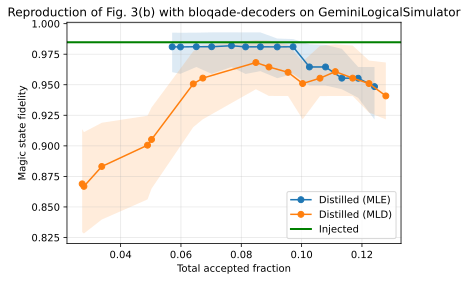

In [71]:
plt.figure(figsize=(6, 4))

plt.plot(
    mle_curve['accepted_fraction'],
    mle_curve['fidelity'],
    marker='o',
    label='Distilled (MLE)',
)
plt.fill_between(
    mle_curve['accepted_fraction'],
    mle_curve['credible'][:, 0],
    mle_curve['credible'][:, 1],
    alpha=0.15,
)

plt.plot(
    mld_curve['accepted_fraction'],
    mld_curve['fidelity'],
    marker='o',
    label='Distilled (MLD)',
)
plt.fill_between(
    mld_curve['accepted_fraction'],
    mld_curve['credible'][:, 0],
    mld_curve['credible'][:, 1],
    alpha=0.15,
)

plt.axhline(
    injected_summary['median'],
    color='green',
    linewidth=2,
    label='Injected',
)
plt.axhspan(
    injected_summary['low'],
    injected_summary['high'],
    color='green',
    alpha=0.12,
)

plt.xlabel('Total accepted fraction')
plt.ylabel('Magic state fidelity')
plt.title('Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Debugging why the plot is bad

In [33]:
def summarize_noiseless(task, shots=256, label=""):
    data = run_task(task, shots, with_noise=False)
    obs = data.observables.astype(np.uint8)
    det = data.detectors.astype(np.uint8)
    print(f"{label} detectors shape:", det.shape)
    print(f"{label} observables shape:", obs.shape)
    print(f"{label} unique detector rows:", len(np.unique(det, axis=0)))
    print(f"{label} unique observable rows:", len(np.unique(obs, axis=0)))
    print(f"{label} output unique:", np.unique(obs[:, 0]))
    print(f"{label} ancilla unique rows:", np.unique(obs[:, 1:], axis=0))
    return data


In [34]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_identity_5():
    reg = qubit.qalloc(5)
    return default_post_processing(reg)

dbg_identity_task = build_task(sim, dbg_identity_5, m2dets=None, m2obs=None)
summarize_noiseless(dbg_identity_task, label="identity_5")

identity_5 detectors shape: (256, 15)
identity_5 observables shape: (256, 5)
identity_5 unique detector rows: 1
identity_5 unique observable rows: 1
identity_5 output unique: [0]
identity_5 ancilla unique rows: [[0 0 0 0]]


BasisDataset(detectors=array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 15), dtype=uint8), observables=array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], shape=(256, 5), dtype=uint8))

In [35]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_cancel():
    reg = qubit.qalloc(5)
    msd_inverse(reg)
    msd_forward(reg)
    return default_post_processing(reg)

dbg_cancel_task = build_task(sim, dbg_cancel, m2dets=None, m2obs=None)
summarize_noiseless(dbg_cancel_task, label="inverse_then_forward")


inverse_then_forward detectors shape: (256, 15)
inverse_then_forward observables shape: (256, 5)
inverse_then_forward unique detector rows: 1
inverse_then_forward unique observable rows: 1
inverse_then_forward output unique: [0]
inverse_then_forward ancilla unique rows: [[0 0 0 0]]


BasisDataset(detectors=array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 15), dtype=uint8), observables=array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], shape=(256, 5), dtype=uint8))

In [36]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_x():
    reg = qubit.qalloc(5)
    tomography_x(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_y():
    reg = qubit.qalloc(5)
    tomography_y(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_z():
    reg = qubit.qalloc(5)
    tomography_z(reg)
    return default_post_processing(reg)

for name, kernel in [("tomo_x", dbg_tomo_x), ("tomo_y", dbg_tomo_y), ("tomo_z", dbg_tomo_z)]:
    task = build_task(sim, kernel, m2dets=None, m2obs=None)
    summarize_noiseless(task, label=name)


tomo_x detectors shape: (256, 15)
tomo_x observables shape: (256, 5)
tomo_x unique detector rows: 1
tomo_x unique observable rows: 2
tomo_x output unique: [0 1]
tomo_x ancilla unique rows: [[0 0 0 0]]
tomo_y detectors shape: (256, 15)
tomo_y observables shape: (256, 5)
tomo_y unique detector rows: 1
tomo_y unique observable rows: 2
tomo_y output unique: [0 1]
tomo_y ancilla unique rows: [[0 0 0 0]]
tomo_z detectors shape: (256, 15)
tomo_z observables shape: (256, 5)
tomo_z unique detector rows: 1
tomo_z unique observable rows: 1
tomo_z output unique: [0]
tomo_z ancilla unique rows: [[0 0 0 0]]


In [37]:
for name, kernel in [("tomo_x", dbg_tomo_x), ("tomo_y", dbg_tomo_y), ("tomo_z", dbg_tomo_z)]:
    task = build_task(sim, kernel, m2dets=None, m2obs=None)
    summarize_noiseless(task, label=name)


tomo_x detectors shape: (256, 15)
tomo_x observables shape: (256, 5)
tomo_x unique detector rows: 1
tomo_x unique observable rows: 2
tomo_x output unique: [0 1]
tomo_x ancilla unique rows: [[0 0 0 0]]
tomo_y detectors shape: (256, 15)
tomo_y observables shape: (256, 5)
tomo_y unique detector rows: 1
tomo_y unique observable rows: 2
tomo_y output unique: [0 1]
tomo_y ancilla unique rows: [[0 0 0 0]]
tomo_z detectors shape: (256, 15)
tomo_z observables shape: (256, 5)
tomo_z unique detector rows: 1
tomo_z unique observable rows: 1
tomo_z output unique: [0]
tomo_z ancilla unique rows: [[0 0 0 0]]


In [38]:
@squin.kernel
def tomography_x_inv(reg):
    squin.h(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_y_inv(reg):
    squin.h(reg[OUTPUT_QUBIT])
    squin.sqrt_z(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_z_inv(reg):
    return


In [39]:
@squin.kernel
def prepare_special_x_v2(reg):
    tomography_x_inv(reg)
    msd_inverse(reg)

@squin.kernel
def prepare_special_y_v2(reg):
    tomography_y_inv(reg)
    msd_inverse(reg)

@squin.kernel
def prepare_special_z_v2(reg):
    tomography_z_inv(reg)
    msd_inverse(reg)


In [40]:
@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_x_v2():
    reg = qubit.qalloc(5)
    prepare_special_x_v2(reg)
    msd_forward(reg)
    tomography_x(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_y_v2():
    reg = qubit.qalloc(5)
    prepare_special_y_v2(reg)
    msd_forward(reg)
    tomography_y(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_z_v2():
    reg = qubit.qalloc(5)
    prepare_special_z_v2(reg)
    msd_forward(reg)
    tomography_z(reg)
    return default_post_processing(reg)

special_v2_tasks = {
    "X": build_task(sim, msd_special_x_v2, m2dets=None, m2obs=None),
    "Y": build_task(sim, msd_special_y_v2, m2dets=None, m2obs=None),
    "Z": build_task(sim, msd_special_z_v2, m2dets=None, m2obs=None),
}

for basis, task in special_v2_tasks.items():
    summarize_noiseless(task, label=f"special_v2_{basis}")


special_v2_X detectors shape: (256, 15)
special_v2_X observables shape: (256, 5)
special_v2_X unique detector rows: 1
special_v2_X unique observable rows: 1
special_v2_X output unique: [0]
special_v2_X ancilla unique rows: [[0 0 0 0]]
special_v2_Y detectors shape: (256, 15)
special_v2_Y observables shape: (256, 5)
special_v2_Y unique detector rows: 1
special_v2_Y unique observable rows: 1
special_v2_Y output unique: [0]
special_v2_Y ancilla unique rows: [[0 0 0 0]]
special_v2_Z detectors shape: (256, 15)
special_v2_Z observables shape: (256, 5)
special_v2_Z unique detector rows: 1
special_v2_Z unique observable rows: 1
special_v2_Z output unique: [0]
special_v2_Z ancilla unique rows: [[0 0 0 0]]


# Additional debug on why plot is bad

In [41]:
for basis, task in actual_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "unique full obs:", np.unique(data.observables, axis=0))
    print(basis, "unique ancilla obs:", np.unique(data.observables[:, 1:], axis=0))


X unique full obs: [[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 0]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 1 0 0]
 [1 1 1 1 0]]
X unique ancilla obs: [[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]
Y unique full obs: [[0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 0 1 1]
 [1 1 1 0 1]
 [1 1 1 1 0]
 [1 1 1 1 1]]
Y uniqu

In [42]:
from collections import Counter

for basis, task in actual_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    anc = data.observables[:, 1:]
    counts = Counter(tuple(map(int, row)) for row in anc)
    print("\n", basis)
    for bitstring, count in counts.most_common(10):
        print(bitstring, count, count / len(anc))



 X
(0, 0, 0, 0) 843 0.1686
(0, 0, 1, 1) 302 0.0604
(1, 0, 0, 1) 293 0.0586
(1, 1, 1, 1) 288 0.0576
(0, 1, 1, 1) 283 0.0566
(0, 1, 0, 0) 280 0.056
(0, 0, 1, 0) 280 0.056
(1, 0, 0, 0) 280 0.056
(1, 1, 1, 0) 277 0.0554
(0, 1, 0, 1) 275 0.055

 Y
(0, 0, 0, 0) 799 0.1598
(1, 1, 1, 0) 577 0.1154
(0, 0, 1, 0) 400 0.08
(1, 0, 1, 0) 359 0.0718
(0, 1, 0, 0) 343 0.0686
(0, 1, 0, 1) 297 0.0594
(1, 0, 0, 0) 287 0.0574
(1, 0, 1, 1) 273 0.0546
(0, 0, 0, 1) 260 0.052
(0, 1, 1, 1) 260 0.052

 Z
(0, 0, 0, 0) 804 0.1608
(1, 0, 0, 1) 360 0.072
(0, 1, 0, 0) 357 0.0714
(0, 0, 1, 1) 347 0.0694
(0, 0, 0, 1) 299 0.0598
(1, 1, 0, 0) 295 0.059
(1, 1, 1, 1) 287 0.0574
(1, 1, 0, 1) 280 0.056
(1, 0, 1, 1) 273 0.0546
(1, 1, 1, 0) 270 0.054


In [43]:
def injected_baseline_debug(task_map, posterior_samples: int, shots: int = 4000):
    print("Evaluating injected baseline with SAME data for train and test")
    corrected = {}

    for basis in BASIS_LABELS:
        dataset = run_task(task_map[basis], shots, with_noise=True)

        print(f"\nBasis {basis}")
        print("det shape:", dataset.detectors.shape, "obs shape:", dataset.observables.shape)

        train_det_obs = np.concatenate(
            [dataset.detectors, dataset.observables], axis=1
        ).astype(bool)

        decoder = TableDecoder.from_det_obs_shots(
            make_shape_only_dem(dataset.detectors.shape[1], dataset.observables.shape[1]),
            train_det_obs,
        )

        bits = []
        for det, obs in zip(dataset.detectors, dataset.observables, strict=True):
            flip = np.asarray(decoder.decode(det.astype(bool)), dtype=np.uint8)
            bits.append(int(obs[0] ^ flip[0]))

        bits = np.asarray(bits, dtype=np.uint8)
        corrected[basis] = bits

        print("post-decoding logical mean:", logical_expectation(bits))
        print("logical ones fraction:", float(np.mean(bits)))

    summary = fidelity_from_counts(
        corrected["X"], corrected["Y"], corrected["Z"], posterior_samples, sign_vector=(1.0, 1.0, 1.0)
    )
    print("\nLeaky injected summary:", summary)
    return summary


In [44]:
_ = injected_baseline_debug(injected_tasks, posterior_samples=5000, shots=4000)


Evaluating injected baseline with SAME data for train and test

Basis X
det shape: (4000, 3) obs shape: (4000, 1)
post-decoding logical mean: 0.5645
logical ones fraction: 0.21775

Basis Y
det shape: (4000, 3) obs shape: (4000, 1)
post-decoding logical mean: 0.556
logical ones fraction: 0.222

Basis Z
det shape: (4000, 3) obs shape: (4000, 1)
post-decoding logical mean: 0.556
logical ones fraction: 0.222

Leaky injected summary: {'point': 0.9839638631482038, 'median': 0.9552334641512523, 'low': 0.9551406837472003, 'high': 0.9553262445553043, 'bloch': (0.5645, 0.556, 0.556)}


# Check naive postselection

In [45]:
def naive_injected_baseline(
    task_map,
    posterior_samples: int,
    shots: int | None = None,
    require_zero_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    if shots is None:
        shots = CONFIG["eval_shots"]

    corrected = {}
    accepted_fractions = {}

    for basis in BASIS_LABELS:
        dataset = run_task(task_map[basis], shots, with_noise=True)

        mask = np.ones(len(dataset.observables), dtype=bool)
        if require_zero_detectors:
            mask &= np.all(dataset.detectors == 0, axis=1)

        corrected[basis] = dataset.observables[mask, 0].astype(np.uint8)
        accepted_fractions[basis] = float(np.mean(mask))

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted injected shots in at least one basis.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=(1.0, 1.0, 1.0)
    )
    summary["accepted_fraction"] = float(np.mean(list(accepted_fractions.values())))
    summary["accepted_fraction_by_basis"] = accepted_fractions
    return summary


def naive_distilled_summary(
    actual_data,
    factory_target,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = True,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    factory_target = np.asarray(factory_target, dtype=np.uint8)

    corrected = {}
    accepted_fractions = {}
    total_kept = 0
    total_shots = 0

    for basis in BASIS_LABELS:
        dataset = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)

        mask = np.all(anc_obs == factory_target, axis=1)

        if require_zero_ancilla_detectors:
            mask &= np.all(anc_det == 0, axis=1)

        if require_zero_all_detectors:
            mask &= np.all(dataset.detectors == 0, axis=1)

        corrected[basis] = dataset.observables[mask, 0].astype(np.uint8)
        accepted_fractions[basis] = float(np.mean(mask))

        total_kept += int(np.sum(mask))
        total_shots += len(mask)

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted distilled shots in at least one basis.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=(1.0, -1.0, 1.0)
    )
    summary["accepted_fraction"] = total_kept / total_shots
    summary["accepted_fraction_by_basis"] = accepted_fractions
    summary["factory_target"] = tuple(int(x) for x in factory_target.tolist())
    return summary


def scan_naive_factory_targets(
    actual_data,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = True,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    patterns = sorted(
        {
            tuple(map(int, row))
            for basis in BASIS_LABELS
            for row in actual_data[basis].observables[:, 1:]
        }
    )

    rows = []
    for pattern in patterns:
        try:
            summary = naive_distilled_summary(
                actual_data,
                pattern,
                posterior_samples=posterior_samples,
                require_zero_ancilla_detectors=require_zero_ancilla_detectors,
                require_zero_all_detectors=require_zero_all_detectors,
                min_accepted_per_basis=min_accepted_per_basis,
            )
        except RuntimeError:
            continue

        rows.append(
            {
                "pattern": pattern,
                "accepted_fraction": summary["accepted_fraction"],
                "median": summary["median"],
                "low": summary["low"],
                "high": summary["high"],
                "bloch": summary["bloch"],
            }
        )

    rows.sort(key=lambda row: row["median"], reverse=True)
    return rows


In [46]:
actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}


In [47]:
inj_raw = naive_injected_baseline(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=False,
)
inj_ps = naive_injected_baseline(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=True,
)

print("Injected raw:", inj_raw)
print("Injected perfect-stabilizer:", inj_ps)


Injected raw: {'point': 0.9685197434473813, 'median': 0.9704252960742179, 'low': 0.9704196218851788, 'high': 0.9704309702632571, 'bloch': (0.5305, 0.54, 0.5525), 'accepted_fraction': 1.0, 'accepted_fraction_by_basis': {'X': 1.0, 'Y': 1.0, 'Z': 1.0}}
Injected perfect-stabilizer: {'point': 0.9889031260786276, 'median': 0.9940709577426088, 'low': 0.9934185505893552, 'high': 0.9947233648958624, 'bloch': (0.5532027527792482, 0.585609243697479, 0.5547981122181437), 'accepted_fraction': 0.9500000000000001, 'accepted_fraction_by_basis': {'X': 0.9445, 'Y': 0.952, 'Z': 0.9535}}


In [48]:
naive_rows = scan_naive_factory_targets(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in naive_rows[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.043583333333333335, 'median': 0.9827580481833399, 'low': 0.9682331399734541, 'high': 0.9915732536983797, 'bloch': (0.6024096385542169, 0.6559139784946236, 0.5906432748538012)}
{'pattern': (0, 1, 1, 0), 'accepted_fraction': 0.01625, 'median': 0.933564871971826, 'low': 0.8912302354062972, 'high': 0.9660598935530724, 'bloch': (0.45454545454545453, 0.43661971830985913, 0.7391304347826086)}
{'pattern': (0, 1, 0, 0), 'accepted_fraction': 0.013, 'median': 0.9297203954913887, 'low': 0.8731267909824263, 'high': 0.9699472740420737, 'bloch': (0.52, 0.6, 0.4642857142857143)}
{'pattern': (1, 0, 0, 0), 'accepted_fraction': 0.01525, 'median': 0.9238151220936364, 'low': 0.8709293601118321, 'high': 0.9669713962559189, 'bloch': (0.5555555555555556, 0.5471698113207547, 0.43283582089552236)}
{'pattern': (0, 0, 0, 1), 'accepted_fraction': 0.014833333333333334, 'median': 0.9061239653042013, 'low': 0.8536564913012173, 'high': 0.9512113585124724, 'bloch': (0.53

In [49]:
best_pattern = naive_rows[0]["pattern"]
naive_best = naive_distilled_summary(
    actual_data,
    best_pattern,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

print("Best naive distilled summary:", naive_best)


Best naive distilled summary: {'point': 1.033750766381348, 'median': 0.9827580481833399, 'low': 0.9682331399734541, 'high': 0.9915732536983797, 'bloch': (0.6024096385542169, 0.6559139784946236, 0.5906432748538012), 'accepted_fraction': 0.043583333333333335, 'accepted_fraction_by_basis': {'X': 0.0415, 'Y': 0.0465, 'Z': 0.04275}, 'factory_target': (0, 0, 0, 0)}


In [50]:
naive_rows_no_flags = scan_naive_factory_targets(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=False,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in naive_rows_no_flags[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.11266666666666666, 'median': 0.9474992339460815, 'low': 0.917596675003658, 'high': 0.9697993775264498, 'bloch': (0.5227272727272727, 0.5782881002087683, 0.43187066974595845)}
{'pattern': (0, 1, 0, 0), 'accepted_fraction': 0.06091666666666667, 'median': 0.7910818076283535, 'low': 0.7606526746535112, 'high': 0.831872269943762, 'bloch': (0.32075471698113206, 0.3920704845814978, 0.3054393305439331)}
{'pattern': (1, 0, 0, 0), 'accepted_fraction': 0.058833333333333335, 'median': 0.7889342132436792, 'low': 0.756015851279468, 'high': 0.8170608288688721, 'bloch': (0.3389830508474576, 0.3497942386831276, 0.31277533039647576)}
{'pattern': (0, 1, 1, 0), 'accepted_fraction': 0.060583333333333336, 'median': 0.7591408208569919, 'low': 0.7267804549344531, 'high': 0.802428686437152, 'bloch': (0.32217573221757323, 0.22764227642276422, 0.371900826446281)}
{'pattern': (1, 0, 1, 1), 'accepted_fraction': 0.0585, 'median': 0.7487753278271067, 'low': 0.72058867

In [51]:
def scan_noiseless_actual_patterns(task_map, shots: int = 10000):
    from collections import Counter, defaultdict

    rows = []
    pattern_output = defaultdict(lambda: {"X": [], "Y": [], "Z": []})
    pattern_counts = Counter()

    for basis in BASIS_LABELS:
        data = run_task(task_map[basis], shots, with_noise=False)
        anc = data.observables[:, 1:]
        out = data.observables[:, 0]
        for a, o in zip(anc, out, strict=True):
            key = tuple(int(x) for x in a)
            pattern_counts[key] += 1
            pattern_output[key][basis].append(int(o))

    total = sum(pattern_counts.values())

    for key, count in pattern_counts.items():
        if min(len(pattern_output[key][b]) for b in BASIS_LABELS) == 0:
            continue
        x_bits = np.asarray(pattern_output[key]["X"], dtype=np.uint8)
        y_bits = np.asarray(pattern_output[key]["Y"], dtype=np.uint8)
        z_bits = np.asarray(pattern_output[key]["Z"], dtype=np.uint8)
        summary = fidelity_from_counts(x_bits, y_bits, z_bits, posterior_samples=5000, sign_vector=(1.0, -1.0, 1.0))
        rows.append({
            "pattern": key,
            "fraction": count / total,
            "median": summary["median"],
            "bloch": summary["bloch"],
        })

    rows.sort(key=lambda row: row["median"], reverse=True)
    return rows

rows_noiseless = scan_noiseless_actual_patterns(actual_tasks, shots=10000)
for row in rows_noiseless[:10]:
    print(row)


{'pattern': (1, 1, 0, 1), 'fraction': 0.0559, 'median': 0.9924233401580821, 'bloch': (0.5605536332179931, 0.6765285996055227, 0.5236486486486487)}
{'pattern': (0, 0, 0, 0), 'fraction': 0.16353333333333334, 'median': 0.9783070154867569, 'bloch': (0.5800118976799524, 0.8409785932721713, 0.5911949685534591)}
{'pattern': (0, 0, 0, 1), 'fraction': 0.05316666666666667, 'median': 0.9574301673805462, 'bloch': (0.5265151515151515, 0.43775100401606426, 0.5641476274165202)}
{'pattern': (1, 0, 1, 1), 'fraction': 0.0536, 'median': 0.9291301342698294, 'bloch': (0.5942028985507246, 0.34285714285714286, 0.5865724381625441)}
{'pattern': (0, 1, 1, 0), 'fraction': 0.05196666666666667, 'median': 0.8230416742254685, 'bloch': (0.5978835978835979, 0.0365296803652968, 0.5306859205776173)}
{'pattern': (0, 1, 0, 0), 'fraction': 0.06526666666666667, 'median': 0.8225487752824748, 'bloch': (0.621160409556314, 0.20356612184249628, 0.34763948497854075)}
{'pattern': (1, 0, 0, 0), 'fraction': 0.0496, 'median': 0.78850

In [52]:
import itertools
import numpy as np

def clifford_images_of_magic():
    base = np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0)
    images = []
    for perm in itertools.permutations(range(3)):
        for signs in itertools.product([-1, 1], repeat=3):
            vec = np.array([signs[i] * base[perm[i]] for i in range(3)])
            # Keep proper signed permutations from the single-qubit Clifford group
            mat = np.zeros((3, 3), dtype=int)
            for i in range(3):
                mat[i, perm[i]] = signs[i]
            if round(np.linalg.det(mat)) == 1:
                images.append(tuple(np.round(vec, 8)))
    images = sorted(set(images))
    return [np.array(v) for v in images]

def nearest_magic_image(bloch):
    bloch = np.array(bloch, dtype=float)
    candidates = clifford_images_of_magic()
    scored = []
    for cand in candidates:
        scored.append((float(np.dot(bloch, cand)), cand))
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:5]

# Example: inspect the suspected accepted branch
bloch = np.array([0.5919335705812574, -0.8640429338103757, 0.5940298507462687])
for score, cand in nearest_magic_image(bloch):
    print("score:", score, "candidate:", cand)


score: 1.1835717226405835 candidate: [ 0.57735027 -0.57735027  0.57735027]
score: 0.5000657090462775 candidate: [-0.57735027 -0.57735027  0.57735027]
score: 0.4976451332077477 candidate: [ 0.57735027 -0.57735027 -0.57735027]
score: 0.1858608803865584 candidate: [0.57735027 0.57735027 0.57735027]
score: -0.1858608803865584 candidate: [-0.57735027 -0.57735027 -0.57735027]


In [53]:
for basis, task in injected_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    bits = data.observables[:, 0].astype(np.uint8)
    print(basis, logical_expectation(bits))


X 0.5756
Y 0.5768
Z 0.5896


In [54]:
for basis, task in injected_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    bits = data.observables[:, 0].astype(np.uint8)
    print(basis, logical_expectation(bits))


X 0.5728
Y 0.582
Z 0.576


# Test naive postselection

In [55]:
def naive_injected_summary(
    task_map,
    posterior_samples: int,
    shots: int | None = None,
    require_zero_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    if shots is None:
        shots = CONFIG["eval_shots"]

    corrected = {}
    accepted_fraction_by_basis = {}

    for basis in BASIS_LABELS:
        data = run_task(task_map[basis], shots, with_noise=True)
        mask = np.ones(len(data.observables), dtype=bool)

        if require_zero_detectors:
            mask &= np.all(data.detectors == 0, axis=1)

        corrected[basis] = data.observables[mask, 0].astype(np.uint8)
        accepted_fraction_by_basis[basis] = float(np.mean(mask))

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted injected shots.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=(1.0, 1.0, 1.0),
    )
    summary["accepted_fraction"] = float(np.mean(list(accepted_fraction_by_basis.values())))
    summary["accepted_fraction_by_basis"] = accepted_fraction_by_basis
    return summary


In [56]:
def naive_distilled_summary(
    actual_data,
    factory_target,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = False,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    factory_target = np.asarray(factory_target, dtype=np.uint8)

    corrected = {}
    accepted_fraction_by_basis = {}
    total_kept = 0
    total_shots = 0

    for basis in BASIS_LABELS:
        data = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(data.detectors, data.observables)

        mask = np.all(anc_obs == factory_target, axis=1)

        if require_zero_ancilla_detectors:
            mask &= np.all(anc_det == 0, axis=1)

        if require_zero_all_detectors:
            mask &= np.all(data.detectors == 0, axis=1)

        corrected[basis] = data.observables[mask, 0].astype(np.uint8)
        accepted_fraction_by_basis[basis] = float(np.mean(mask))
        total_kept += int(np.sum(mask))
        total_shots += len(mask)

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted distilled shots.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=(1.0, -1.0, 1.0),
    )
    summary["accepted_fraction"] = total_kept / total_shots
    summary["accepted_fraction_by_basis"] = accepted_fraction_by_basis
    summary["factory_target"] = tuple(int(x) for x in factory_target.tolist())
    return summary


In [57]:
def scan_naive_patterns(
    actual_data,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = False,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    patterns = sorted({
        tuple(map(int, row))
        for basis in BASIS_LABELS
        for row in actual_data[basis].observables[:, 1:]
    })

    rows = []
    for pattern in patterns:
        try:
            s = naive_distilled_summary(
                actual_data,
                pattern,
                posterior_samples=posterior_samples,
                require_zero_ancilla_detectors=require_zero_ancilla_detectors,
                require_zero_all_detectors=require_zero_all_detectors,
                min_accepted_per_basis=min_accepted_per_basis,
            )
        except RuntimeError:
            continue

        rows.append({
            "pattern": pattern,
            "accepted_fraction": s["accepted_fraction"],
            "median": s["median"],
            "low": s["low"],
            "high": s["high"],
            "bloch": s["bloch"],
        })

    rows.sort(key=lambda r: r["median"], reverse=True)
    return rows


In [58]:
actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}

inj_raw = naive_injected_summary(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=False,
)

inj_ps = naive_injected_summary(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=True,
)

print("Injected raw:", inj_raw)
print("Injected perfect-stabilizer:", inj_ps)


Injected raw: {'point': 0.9742932461392776, 'median': 0.9704270092787506, 'low': 0.970421340547559, 'high': 0.9704326780099423, 'bloch': (0.538, 0.551, 0.554), 'accepted_fraction': 1.0, 'accepted_fraction_by_basis': {'X': 1.0, 'Y': 1.0, 'Z': 1.0}}
Injected perfect-stabilizer: {'point': 0.9973025736035235, 'median': 0.993391612054308, 'low': 0.9873543433194208, 'high': 0.9945059784092686, 'bloch': (0.5732634338138926, 0.587503309504898, 0.5619399051133368), 'accepted_fraction': 0.9488333333333334, 'accepted_fraction_by_basis': {'X': 0.95375, 'Y': 0.94425, 'Z': 0.9485}}


In [59]:
rows_no_decoder = scan_naive_patterns(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=False,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in rows_no_decoder[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.11733333333333333, 'median': 0.9272147518888145, 'low': 0.9152728998383058, 'high': 0.9443487206122476, 'bloch': (0.4730290456431535, 0.5154185022026432, 0.5084745762711864)}
{'pattern': (0, 1, 0, 0), 'accepted_fraction': 0.06175, 'median': 0.7853951514014342, 'low': 0.7487767842918336, 'high': 0.8066657643543356, 'bloch': (0.3891213389121339, 0.28225806451612906, 0.2992125984251969)}
{'pattern': (1, 0, 1, 1), 'accepted_fraction': 0.059416666666666666, 'median': 0.7539928338078686, 'low': 0.7234204706324864, 'high': 0.7853819777118493, 'bloch': (0.2697095435684647, 0.2914798206278027, 0.3413654618473896)}
{'pattern': (1, 0, 0, 0), 'accepted_fraction': 0.058333333333333334, 'median': 0.7483429071142323, 'low': 0.7173359841216701, 'high': 0.7878058464061967, 'bloch': (0.3094170403587444, 0.33613445378151263, 0.2217573221757322)}
{'pattern': (0, 1, 1, 0), 'accepted_fraction': 0.05825, 'median': 0.7009181193391495, 'low': 0.6722164500743791,

In [60]:
rows_no_decoder_flagged = scan_naive_patterns(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in rows_no_decoder_flagged[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.04541666666666667, 'median': 0.984657465203227, 'low': 0.9669722194666946, 'high': 0.9935799148258154, 'bloch': (0.5879396984924623, 0.5925925925925926, 0.6739130434782609)}
{'pattern': (1, 0, 1, 1), 'accepted_fraction': 0.014083333333333333, 'median': 0.9666204520565315, 'low': 0.9393349723732598, 'high': 0.9865158906339919, 'bloch': (0.6, 0.6078431372549019, 0.7586206896551724)}
{'pattern': (0, 1, 0, 0), 'accepted_fraction': 0.014583333333333334, 'median': 0.9496187737305656, 'low': 0.9139072520312773, 'high': 0.9712903528567641, 'bloch': (0.7377049180327869, 0.40350877192982454, 0.6491228070175439)}
{'pattern': (1, 1, 0, 1), 'accepted_fraction': 0.015, 'median': 0.939271634502486, 'low': 0.8961100245246929, 'high': 0.9731716120496984, 'bloch': (0.4576271186440678, 0.660377358490566, 0.5294117647058824)}
{'pattern': (0, 1, 0, 1), 'accepted_fraction': 0.01425, 'median': 0.4319570986736682, 'low': 0.3739973922830624, 'high': 0.4864147227

In [61]:
best_raw = rows_no_decoder[0]
best_flagged = rows_no_decoder_flagged[0]

print("Best naive raw branch:", best_raw)
print("Best naive flagged branch:", best_flagged)
print("Injected raw median:", inj_raw["median"])
print("Injected perfect-stabilizer median:", inj_ps["median"])


Best naive raw branch: {'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.11733333333333333, 'median': 0.9272147518888145, 'low': 0.9152728998383058, 'high': 0.9443487206122476, 'bloch': (0.4730290456431535, 0.5154185022026432, 0.5084745762711864)}
Best naive flagged branch: {'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.04541666666666667, 'median': 0.984657465203227, 'low': 0.9669722194666946, 'high': 0.9935799148258154, 'bloch': (0.5879396984924623, 0.5925925925925926, 0.6739130434782609)}
Injected raw median: 0.9704270092787506
Injected perfect-stabilizer median: 0.993391612054308
